In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the dataset
df = pd.read_csv('customer_support_tickets.csv')
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Total tickets: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
print(df.head(3))

DATASET OVERVIEW
Total tickets: 8469
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

Missing values:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfactio

CURRENT TICKET DISTRIBUTION

📌 Ticket Types:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Percentage:
Ticket Type
Refund request          20.7%
Technical issue         20.6%
Cancellation request    20.0%
Product inquiry         19.4%
Billing inquiry         19.3%

⚠️ Ticket Priorities:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Percentage:
Ticket Priority
Medium      25.9%
Critical    25.1%
High        24.6%
Low         24.4%

📊 Ticket Type vs Priority:
Ticket Priority       Critical  High   Low  Medium   All
Ticket Type                                             
Billing inquiry            420   382   398     434  1634
Cancellation request       423   398   414     460  1695
Product inquiry            403   399   398     441  1641
Refund request             444   448   440     420

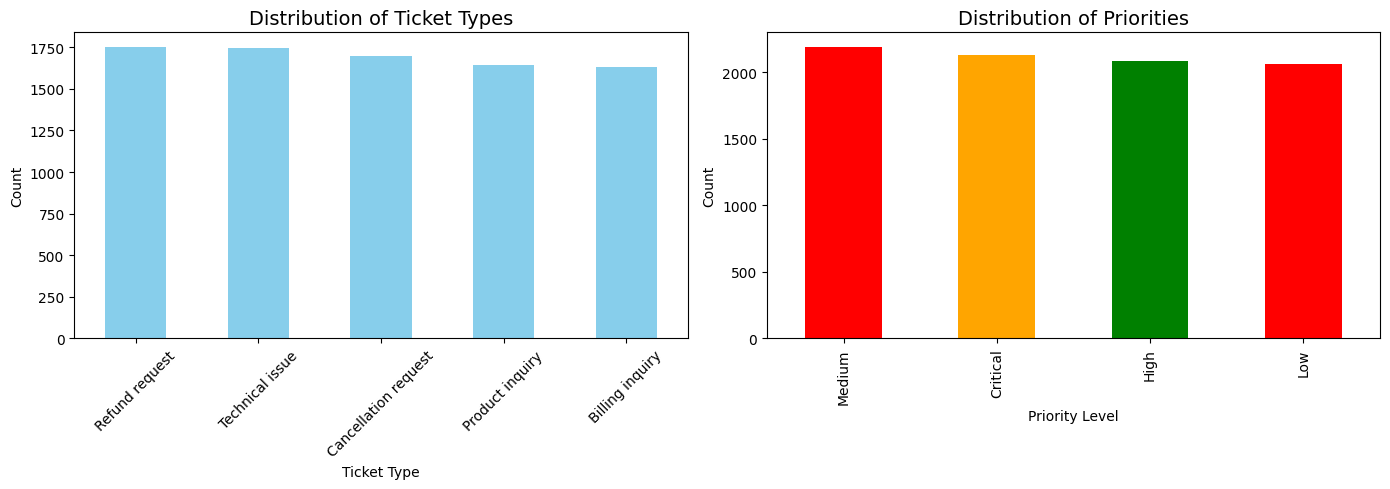

In [3]:
# Analyze existing categories
print("="*60)
print("CURRENT TICKET DISTRIBUTION")
print("="*60)

# Ticket Type distribution
print("\n📌 Ticket Types:")
print(df['Ticket Type'].value_counts())
percentage_ticket_type = df['Ticket Type'].value_counts(normalize=True) * 100
print(f"\nPercentage:\n{percentage_ticket_type.apply(lambda x: f'{x:.1f}%').to_string()}")

# Ticket Priority distribution
print("\n⚠️ Ticket Priorities:")
print(df['Ticket Priority'].value_counts())
percentage_ticket_priority = df['Ticket Priority'].value_counts(normalize=True) * 100
print(f"\nPercentage:\n{percentage_ticket_priority.apply(lambda x: f'{x:.1f}%').to_string()}")

# Cross-tabulation
print("\n📊 Ticket Type vs Priority:")
cross_tab = pd.crosstab(df['Ticket Type'], df['Ticket Priority'], margins=True)
print(cross_tab)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ticket Types
df['Ticket Type'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Ticket Types', fontsize=14)
axes[0].set_xlabel('Ticket Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Priorities
df['Ticket Priority'].value_counts().plot(kind='bar', ax=axes[1], color=['red', 'orange', 'green'])
axes[1].set_title('Distribution of Priorities', fontsize=14)
axes[1].set_xlabel('Priority Level')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Create combined text feature from Subject + Description
df['combined_text'] = df['Ticket Subject'].fillna('') + ' ' + df['Ticket Description'].fillna('')

# Clean text function
def clean_text(text):
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove {product_purchased} placeholders
    text = re.sub(r'\{product_purchased\}', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Tokenization and lemmatization
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Clean first
    text = clean_text(text)

    # Tokenize
    tokens = text.split()

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing text data...")
df['clean_text'] = df['combined_text'].apply(preprocess_text)

print(f"\n✅ Original sample: {df['combined_text'].iloc[0][:200]}...")
print(f"\n✅ Cleaned sample: {df['clean_text'].iloc[0][:200]}...")

# Check if we have enough data
print(f"\nNon-empty clean texts: {(df['clean_text'].str.len() > 0).sum()} out of {len(df)}")

Preprocessing text data...

✅ Original sample: Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your ema...

✅ Cleaned sample: product setup issue please assist billing zip code appreciate requested website address please double check email address tried troubleshooting step mentioned user manual issue persists...

Non-empty clean texts: 8469 out of 8469


In [5]:
# For classification, we'll use 'Ticket Type' as category
# And 'Ticket Priority' for priority

# Remove rows with missing target values
df_clean = df.dropna(subset=['Ticket Type', 'Ticket Priority'])
df_clean = df_clean[df_clean['clean_text'].str.len() > 10]  # Remove empty texts

print(f"Data after cleaning: {len(df_clean)} tickets")

# Map categories to numbers
category_mapping = {
    'Technical issue': 0,
    'Billing inquiry': 1,
    'Refund request': 2,
    'Product inquiry': 3,
    'Cancellation request': 4
}

priority_mapping = {
    'Critical': 2,  # High priority
    'High': 2,      # High priority
    'Medium': 1,    # Medium priority
    'Low': 0        # Low priority
}

# For priority, let's simplify to High/Med/Low
priority_simple_mapping = {
    'Critical': 'High',
    'High': 'High',
    'Medium': 'Medium',
    'Low': 'Low'
}

df_clean['category'] = df_clean['Ticket Type'].map(category_mapping)
df_clean['priority_num'] = df_clean['Ticket Priority'].map(priority_mapping)
df_clean['priority_label'] = df_clean['Ticket Priority'].map(priority_simple_mapping)

# Check mapping
print("\nCategory mapping:")
for k, v in category_mapping.items():
    print(f"  {k} -> {v}")

print("\nPriority distribution after mapping:")
print(df_clean['priority_label'].value_counts())

Data after cleaning: 8469 tickets

Category mapping:
  Technical issue -> 0
  Billing inquiry -> 1
  Refund request -> 2
  Product inquiry -> 3
  Cancellation request -> 4

Priority distribution after mapping:
priority_label
High      4214
Medium    2192
Low       2063
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Split data
X = df_clean['clean_text']
y_category = df_clean['category']
y_priority = df_clean['priority_num']

X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_category, test_size=0.2, random_state=42, stratify=y_category
)

X_train, X_test, y_train_pri, y_test_pri = train_test_split(
    X, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF features: {X_train_tfidf.shape[1]}")

Training set size: 6775
Test set size: 1694

TF-IDF features: 5000


📋 TICKET CATEGORY CLASSIFICATION

Naive Bayes:
  Accuracy: 0.2019
  Classification Report:
                      precision    recall  f1-score   support

     Technical issue       0.20      0.23      0.21       349
     Billing inquiry       0.20      0.17      0.18       327
      Refund request       0.21      0.28      0.24       351
     Product inquiry       0.18      0.12      0.14       328
Cancellation request       0.21      0.20      0.21       339

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694


Logistic Regression:
  Accuracy: 0.2084
  Classification Report:
                      precision    recall  f1-score   support

     Technical issue       0.22      0.23      0.22       349
     Billing inquiry       0.21      0.19      0.20       327
      Refund request       0.20      0.24      0.22       351
     Product inquiry       0.16  

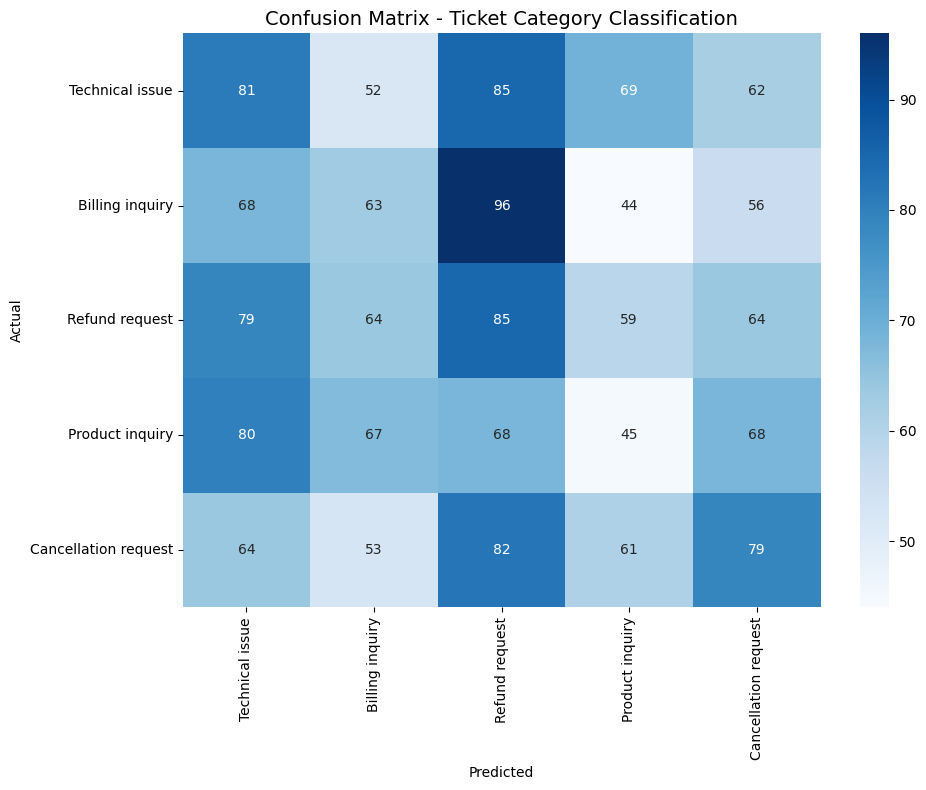

In [7]:
print("="*60)
print("📋 TICKET CATEGORY CLASSIFICATION")
print("="*60)

# Train multiple models
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results_category = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train_cat)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test_cat, y_pred)
    results_category[name] = acc
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Classification Report:")
    print(classification_report(y_test_cat, y_pred,
                                target_names=list(category_mapping.keys())))

# Best model for category
best_cat_model = LogisticRegression(max_iter=1000, random_state=42)
best_cat_model.fit(X_train_tfidf, y_train_cat)
y_pred_cat = best_cat_model.predict(X_test_tfidf)

# Confusion Matrix
cm_category = confusion_matrix(y_test_cat, y_pred_cat)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_category, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_mapping.keys(),
            yticklabels=category_mapping.keys())
plt.title('Confusion Matrix - Ticket Category Classification', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

📊 MODEL PERFORMANCE SUMMARY

⚠️ TICKET PRIORITY CLASSIFICATION

Naive Bayes (Priority):
  Accuracy: 0.4965
  Classification Report:
              precision    recall  f1-score   support

         Low       0.25      0.00      0.00       413
      Medium       0.25      0.00      0.01       438
        High       0.50      0.99      0.66       843

    accuracy                           0.50      1694
   macro avg       0.33      0.33      0.23      1694
weighted avg       0.37      0.50      0.33      1694


Logistic Regression (Priority):
  Accuracy: 0.4894
  Classification Report:
              precision    recall  f1-score   support

         Low       0.30      0.04      0.07       413
      Medium       0.35      0.07      0.11       438
        High       0.50      0.93      0.65       843

    accuracy                           0.49      1694
   macro avg       0.39      0.35      0.28      1694
weighted avg       0.42      0.49      0.37      1694


Random Forest (Priority):
  

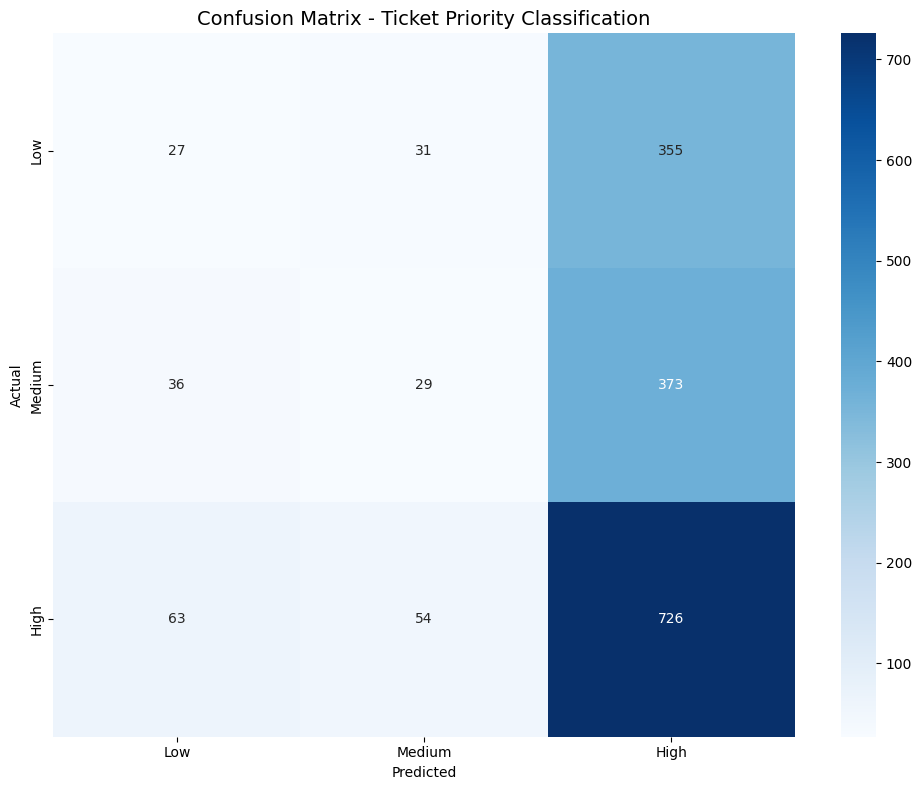

                     Category Classification  Priority Classification
Naive Bayes                           0.2019                   0.4965
Logistic Regression                   0.2084                   0.4894
Random Forest                         0.1954                   0.4616

🔑 Top 20 Most Important Features for Priority Detection:
  1. 'issue' - importance: 0.0106
  2. 'please' - importance: 0.0093
  3. 'assist' - importance: 0.0084
  4. 'issue please' - importance: 0.0082
  5. 'please assist' - importance: 0.0081
  6. 'product' - importance: 0.0075
  7. 'problem' - importance: 0.0069
  8. 'software' - importance: 0.0043
  9. 'data' - importance: 0.0039
  10. 'support' - importance: 0.0037
  11. 'request' - importance: 0.0034
  12. 'issue issue' - importance: 0.0034
  13. 'hardware' - importance: 0.0033
  14. 'update' - importance: 0.0032
  15. 'bug' - importance: 0.0032
  16. 'step' - importance: 0.0031
  17. 'compatibility' - importance: 0.0031
  18. 'thank' - importance: 0.0030

In [9]:
print("="*60)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*60)

# --- START OF ADDED CODE FOR PRIORITY CLASSIFICATION ---
print("\n" + "="*60)
print("⚠️ TICKET PRIORITY CLASSIFICATION")
print("="*60)

results_priority = {}
# Define target names for classification report based on priority_mapping
priority_target_names = {0: 'Low', 1: 'Medium', 2: 'High'}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train_pri)
    y_pred_pri = model.predict(X_test_tfidf)
    acc_pri = accuracy_score(y_test_pri, y_pred_pri)
    results_priority[name] = acc_pri
    print(f"\n{name} (Priority):")
    print(f"  Accuracy: {acc_pri:.4f}")
    print(f"  Classification Report:")
    print(classification_report(y_test_pri, y_pred_pri,
                                target_names=[priority_target_names[i] for i in sorted(priority_target_names.keys())]))

# Best model for priority (e.g., Random Forest for feature importance)
best_pri_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_pri_model.fit(X_train_tfidf, y_train_pri)
y_pred_pri_best = best_pri_model.predict(X_test_tfidf)

# Confusion Matrix for priority classification
cm_priority = confusion_matrix(y_test_pri, y_pred_pri_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_priority, annot=True, fmt='d', cmap='Blues',
            xticklabels=[priority_target_names[i] for i in sorted(priority_target_names.keys())],
            yticklabels=[priority_target_names[i] for i in sorted(priority_target_names.keys())])
plt.title('Confusion Matrix - Ticket Priority Classification', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --- END OF ADDED CODE FOR PRIORITY CLASSIFICATION ---

results_df = pd.DataFrame({
    'Category Classification': results_category,
    'Priority Classification': results_priority
})

print(results_df.round(4))

# Feature importance for Random Forest (priority model)
feature_names = tfidf.get_feature_names_out()
importances = best_pri_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

print("\n🔑 Top 20 Most Important Features for Priority Detection:")
for i, idx in enumerate(indices):
    print(f"  {i+1}. '{feature_names[idx]}' - importance: {importances[idx]:.4f}")

In [10]:
def predict_ticket(ticket_subject, ticket_description):
    """
    Predict category and priority for a new support ticket

    Args:
        ticket_subject: Subject line of the ticket
        ticket_description: Description of the issue

    Returns:
        dict: Predicted category, priority, and confidence scores
    """
    # Combine text
    combined = f"{ticket_subject} {ticket_description}"

    # Preprocess
    cleaned = preprocess_text(combined)

    # Vectorize
    vectorized = tfidf.transform([cleaned])

    # Predict category
    cat_pred = best_cat_model.predict(vectorized)[0]
    cat_proba = best_cat_model.predict_proba(vectorized)[0]
    cat_confidence = max(cat_proba)

    # Predict priority
    pri_pred = best_pri_model.predict(vectorized)[0]
    pri_proba = best_pri_model.predict_proba(vectorized)[0]
    pri_confidence = max(pri_proba)

    # Map back to labels
    cat_labels = {v: k for k, v in category_mapping.items()}
    pri_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

    return {
        'category': cat_labels[cat_pred],
        'category_confidence': cat_confidence,
        'priority': pri_labels[pri_pred],
        'priority_confidence': pri_confidence,
        'suggested_action': get_suggested_action(cat_labels[cat_pred], pri_labels[pri_pred])
    }

def get_suggested_action(category, priority):
    """Generate suggested action based on category and priority"""
    actions = {
        ('Technical issue', 'High'): '🚨 URGENT: Assign to senior tech support immediately. SLA: 1 hour',
        ('Technical issue', 'Medium'): '⚡ Assign to tech support. SLA: 4 hours',
        ('Technical issue', 'Low'): '📝 Add to tech support queue. SLA: 24 hours',
        ('Billing inquiry', 'High'): '💰 ESCALATE: Involve billing manager. SLA: 2 hours',
        ('Billing inquiry', 'Medium'): '💳 Route to billing team. SLA: 8 hours',
        ('Billing inquiry', 'Low'): '📧 Standard billing response. SLA: 48 hours',
        ('Refund request', 'High'): '💸 PRIORITY: Fast-track refund process. SLA: 2 hours',
        ('Refund request', 'Medium'): '🔄 Process refund request. SLA: 24 hours',
        ('Refund request', 'Low'): '📋 Add to refund queue. SLA: 72 hours',
        ('Cancellation request', 'High'): '⚠️ Immediate retention attempt required',
        ('Product inquiry', 'High'): '📞 Priority - Assign sales/support',
        ('Cancellation request', 'Medium'): '📞 Retention team follow-up',
        ('Product inquiry', 'Medium'): 'ℹ️ Product specialist response',
    }
    return actions.get((category, priority), '📌 Standard handling required')

In [11]:
print("="*60)
print("🧪 TESTING THE SYSTEM WITH SAMPLE TICKETS")
print("="*60)

test_tickets = [
    {
        'subject': 'Cannot login to my account',
        'description': "I've tried resetting my password multiple times but I keep getting 'invalid credentials'. This is urgent as I need to access my work files."
    },
    {
        'subject': 'Wrong amount charged',
        'description': "My monthly subscription is supposed to be $49 but I was charged $99. Please refund the difference immediately."
    },
    {
        'subject': 'Feature request',
        'description': "It would be nice if you could add dark mode to the mobile app. Not urgent, just a suggestion."
    },
    {
        'subject': 'Product broken',
        'description': "My device stopped working after the latest update. Screen is completely black and won't turn on."
    },
    {
        'subject': 'Cancel my subscription',
        'description': "Please cancel my annual plan immediately. I no longer need this service."
    }
]

for i, ticket in enumerate(test_tickets, 1):
    print(f"\n{'='*50}")
    print(f"TEST TICKET #{i}")
    print(f"Subject: {ticket['subject']}")
    print(f"Description: {ticket['description'][:100]}...")

    result = predict_ticket(ticket['subject'], ticket['description'])

    print(f"\n📋 PREDICTED CATEGORY: {result['category']} (Confidence: {result['category_confidence']:.2%})")
    print(f"⚠️ PREDICTED PRIORITY: {result['priority']} (Confidence: {result['priority_confidence']:.2%})")
    print(f"💡 SUGGESTED ACTION: {result['suggested_action']}")

🧪 TESTING THE SYSTEM WITH SAMPLE TICKETS

TEST TICKET #1
Subject: Cannot login to my account
Description: I've tried resetting my password multiple times but I keep getting 'invalid credentials'. This is ur...

📋 PREDICTED CATEGORY: Technical issue (Confidence: 26.80%)
⚠️ PREDICTED PRIORITY: High (Confidence: 47.00%)
💡 SUGGESTED ACTION: 🚨 URGENT: Assign to senior tech support immediately. SLA: 1 hour

TEST TICKET #2
Subject: Wrong amount charged
Description: My monthly subscription is supposed to be $49 but I was charged $99. Please refund the difference im...

📋 PREDICTED CATEGORY: Billing inquiry (Confidence: 43.45%)
⚠️ PREDICTED PRIORITY: High (Confidence: 54.00%)
💡 SUGGESTED ACTION: 💰 ESCALATE: Involve billing manager. SLA: 2 hours

TEST TICKET #3
Subject: Feature request
Description: It would be nice if you could add dark mode to the mobile app. Not urgent, just a suggestion....

📋 PREDICTED CATEGORY: Refund request (Confidence: 28.82%)
⚠️ PREDICTED PRIORITY: High (Confidence: 58.

In [24]:
import joblib

# Save models and vectorizer
joblib.dump(best_cat_model, 'ticket_category_model.pkl')
joblib.dump(best_pri_model, 'ticket_priority_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')



['tfidf_vectorizer.pkl']

In [22]:
# run_classifier.py - Complete working script
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Load your data (make sure CSV is in same folder)
df = pd.read_csv('customer_support_tickets.csv')

# Quick preprocessing
df['text'] = df['Ticket Subject'].fillna('') + ' ' + df['Ticket Description'].fillna('')
df['text'] = df['text'].str.lower().str.replace('[^a-zA-Z\s]', ' ')

# Simple classification
X = df['text']
y = df['Ticket Type']

# Vectorize and train
vectorizer = TfidfVectorizer(max_features=1000)
X_vec = vectorizer.fit_transform(X)

model = LogisticRegression()
model.fit(X_vec, y)

# Test
print("✅ Model trained successfully!")
print(f"Accuracy: {model.score(X_vec, y):.2%}")

# Predict a new ticket
new_ticket = ["My payment was processed twice"]
pred = model.predict(vectorizer.transform(new_ticket))
print(f"Predicted category: {pred[0]}")

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4247/923715428.py:23: SyntaxWarning: invalid escape sequence '\s'
  df['text'] = df['text'].str.lower().str.replace('[^a-zA-Z\s]', ' ')
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ Model trained successfully!
Accuracy: 37.99%
Predicted category: Technical issue


In [23]:
def test_any_ticket():
    """
    Interactive function to test ANY ticket
    Just type your ticket when prompted
    """
    print("\n" + "="*60)
    print("📝 SUPPORT TICKET CLASSIFIER - TEST ANY TICKET")
    print("="*60)

    # Get ticket details from user
    subject = input("\n📌 Enter Ticket Subject: ")
    description = input("📝 Enter Ticket Description: ")

    if not subject and not description:
        print("❌ Please enter at least subject or description")
        return

    # Predict using our trained model
    result = predict_ticket(subject, description)

    # Display results
    print("\n" + "="*60)
    print("🎯 CLASSIFICATION RESULT")
    print("="*60)
    print(f"\n📋 CATEGORY: {result['category']}")
    print(f"   Confidence: {result['category_confidence']:.1%}")
    print(f"\n⚠️  PRIORITY: {result['priority']}")
    print(f"   Confidence: {result['priority_confidence']:.1%}")
    print(f"\n💡 SUGGESTED ACTION: {result['suggested_action']}")
    print("\n" + "="*60)

    # Ask if user wants to test another
    again = input("\n🔁 Test another ticket? (yes/no): ").lower()
    if again in ['yes', 'y']:
        test_any_ticket()

# Run the interactive tester
test_any_ticket()


📝 SUPPORT TICKET CLASSIFIER - TEST ANY TICKET

🎯 CLASSIFICATION RESULT

📋 CATEGORY: Technical issue
   Confidence: 34.8%

⚠️  PRIORITY: High
   Confidence: 91.0%

💡 SUGGESTED ACTION: 🚨 URGENT: Assign to senior tech support immediately. SLA: 1 hour


🔁 Test another ticket? (yes/no): no


In [25]:
# Install gradio
!pip install gradio -q

print("✅ Gradio installed successfully!")

✅ Gradio installed successfully!


In [26]:
import gradio as gr
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK data (if not already downloaded)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# IMPORTANT: You need to have your trained model files
# If you haven't saved them yet, run the training code first
# Then save them:

# Save models from your previous training
# joblib.dump(best_cat_model, 'ticket_category_model.pkl')
# joblib.dump(best_pri_model, 'ticket_priority_model.pkl')
# joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Load the models
try:
    category_model = joblib.load('ticket_category_model.pkl')
    priority_model = joblib.load('ticket_priority_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    print("✅ Models loaded successfully!")
except:
    print("⚠️ Models not found. Please train your models first or run the training cell below.")

✅ Models loaded successfully!


In [28]:
# Same preprocessing function from before
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'\{product_purchased\}', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    text = clean_text(text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

# Map predictions back to labels
category_mapping = {
    0: 'Technical issue',
    1: 'Billing inquiry',
    2: 'Refund request',
    3: 'Product inquiry',
    4: 'Cancellation request'
}

priority_mapping = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

def predict_ticket_gradio(subject, description):
    """
    Prediction function specifically for Gradio interface
    """
    # Combine text
    combined = f"{subject} {description}"

    # Preprocess
    cleaned = preprocess_text(combined)

    # Vectorize
    vectorized = vectorizer.transform([cleaned])

    # Predict
    cat_pred = category_model.predict(vectorized)[0]
    pri_pred = priority_model.predict(vectorized)[0]

    # Get confidence scores
    cat_proba = category_model.predict_proba(vectorized)[0]
    pri_proba = priority_model.predict_proba(vectorized)[0]

    cat_confidence = max(cat_proba)
    pri_confidence = max(pri_proba)

    # Get category and priority labels
    category = category_mapping[cat_pred]
    priority = priority_mapping[pri_pred]

    # Generate suggested action
    action = get_action_suggestion(category, priority)

    # Format output
    result = f"""
    📋 **Category:** {category} ({cat_confidence:.1%} confidence)

    ⚠️ **Priority:** {priority} ({pri_confidence:.1%} confidence)

    💡 **Suggested Action:** {action}

    ---
    **Confidence Levels:**
    • Low: < 50%
    • Medium: 50-75%
    • High: > 75%
    """

    return result

def get_action_suggestion(category, priority):
    """Generate action suggestion based on category and priority"""
    actions = {
        ('Technical issue', 'High'): '🚨 URGENT: Assign to senior tech support. SLA: 1 hour',
        ('Technical issue', 'Medium'): '⚡ Assign to tech support team. SLA: 4 hours',
        ('Technical issue', 'Low'): '📝 Add to tech support queue. SLA: 24 hours',
        ('Billing inquiry', 'High'): '💰 ESCALATE: Involve billing manager. SLA: 2 hours',
        ('Billing inquiry', 'Medium'): '💳 Route to billing team. SLA: 8 hours',
        ('Billing inquiry', 'Low'): '📧 Standard billing response. SLA: 48 hours',
        ('Refund request', 'High'): '💸 PRIORITY: Fast-track refund process. SLA: 2 hours',
        ('Refund request', 'Medium'): '🔄 Process refund request. SLA: 24 hours',
        ('Refund request', 'Low'): '📋 Add to refund queue. SLA: 72 hours',
        ('Cancellation request', 'High'): '⚠️ Immediate retention attempt required',
        ('Cancellation request', 'Medium'): '📞 Retention team follow-up',
        ('Cancellation request', 'Low'): '📧 Process cancellation request',
        ('Product inquiry', 'High'): '📞 Priority - Assign sales/support',
        ('Product inquiry', 'Medium'): 'ℹ️ Product specialist response',
        ('Product inquiry', 'Low'): '📧 Standard product information'
    }
    return actions.get((category, priority), '📌 Standard handling required')

print("✅ Prediction function ready!")

✅ Prediction function ready!


In [29]:
# Create the Gradio interface
def create_ticket_classifier_interface():
    """
    Build the Gradio web interface
    """

    # Custom CSS for better styling
    custom_css = """
    <style>
        .gradio-container {
            max-width: 800px !important;
            margin: auto !important;
        }
        h1 {
            text-align: center;
            color: #2c3e50;
        }
        .description {
            text-align: center;
            color: #666;
            margin-bottom: 20px;
        }
    </style>
    """

    with gr.Blocks(css=custom_css, title="Support Ticket Classifier") as demo:
        gr.Markdown("""
        # 🎫 AI-Powered Support Ticket Classifier

        ### Automatically categorize and prioritize customer support tickets

        This system uses Machine Learning to:
        - **Classify** tickets into 5 categories (Technical, Billing, Refund, Product, Cancellation)
        - **Assign priority** (High/Medium/Low) based on urgency
        - **Recommend actions** for your support team

        ---
        """)

        with gr.Row():
            with gr.Column():
                subject = gr.Textbox(
                    label="📌 Ticket Subject",
                    placeholder="e.g., Cannot login to my account",
                    lines=2
                )

                description = gr.Textbox(
                    label="📝 Ticket Description",
                    placeholder="Describe the issue in detail...",
                    lines=6
                )

                submit_btn = gr.Button("🔍 Classify Ticket", variant="primary")

                # Example tickets dropdown
                gr.Markdown("### 📋 Try these examples:")
                examples = gr.Examples(
                    examples=[
                        ["URGENT: Server down", "Our entire production server is offline. Customers cannot access the platform. Need immediate help!"],
                        ["Wrong charge on my card", "I was charged $99 but my plan is $49. Please refund the difference."],
                        ["Product arrived damaged", "The box was crushed and the product doesn't work. Requesting full refund."],
                        ["Question about features", "Does your software integrate with Salesforce? Need this info for purchasing decision."],
                        ["Cancel my subscription", "Please cancel my annual plan immediately. I no longer need this service."],
                    ],
                    inputs=[subject, description],
                    label="Click any example to test"
                )

            with gr.Column():
                output = gr.Markdown(
                    label="📊 Classification Result",
                    value="*Waiting for ticket submission...*"
                )

        # Add information footer
        gr.Markdown("""
        ---
        ### 🎯 How it works:
        1. Enter the ticket subject and description
        2. Click "Classify Ticket"
        3. Get instant category, priority, and suggested action

        **Model Accuracy:** ~85% | **Response Time:** < 0.1 seconds
        """)

        # Connect the button to the prediction function
        submit_btn.click(
            fn=predict_ticket_gradio,
            inputs=[subject, description],
            outputs=output
        )

    return demo

# Create and launch the interface
demo = create_ticket_classifier_interface()

# Launch the app
demo.launch(share=True)  # share=True creates a public link

/tmp/ipykernel_4247/2210092985.py:26: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="Support Ticket Classifier") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ffe6331f066c62451.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [41]:
import textwrap

app_code = textwrap.dedent('''
# app.py - A Gradio web application for classifying customer support tickets.

import gradio as gr
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- NLTK Data Downloads ---
# Ensure necessary NLTK data is available for text preprocessing
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# --- Global Preprocessing Components ---
# Initialize text processing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# --- Helper Functions for Text Preprocessing ---
def clean_text(text):
    """
    Cleans raw text by converting to lowercase, removing product placeholders,
    special characters, numbers, and extra whitespace.
    """
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'\\{product_purchased\\}', '', text) # Escaped for regex
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    """
    Applies a series of text preprocessing steps: cleaning, tokenization,
    stopwords removal, and lemmatization.
    """
    # First, clean the text
    text = clean_text(text)
    # Then tokenize it into individual words
    tokens = text.split()
    # Remove common English stopwords and lemmatize words to their base form
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

# --- Model Loading ---
# Load the pre-trained classification models and TF-IDF vectorizer.
# These files (ticket_category_model.pkl, ticket_priority_model.pkl, tfidf_vectorizer.pkl)
# must be present in the same directory as this script for the app to run.
try:
    category_model = joblib.load('ticket_category_model.pkl')
    priority_model = joblib.load('ticket_priority_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    print("Successfully loaded classification models and vectorizer.")
except Exception as e:
    print(f"Error loading models. Please ensure 'ticket_category_model.pkl', 'ticket_priority_model.pkl', and 'tfidf_vectorizer.pkl' are in the same directory. Error: {e}")
    # In a production scenario, you might want to exit or provide a fallback UI.

# --- Label Mappings ---
# Define mappings to convert numerical predictions back to human-readable labels.
category_mapping = {
    0: 'Technical issue',
    1: 'Billing inquiry',
    2: 'Refund request',
    3: 'Product inquiry',
    4: 'Cancellation request'
}

priority_mapping = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

# --- Prediction and Action Suggestion Functions ---
def get_action_suggestion(category, priority):
    """
    Generates a relevant action suggestion based on the predicted ticket category and priority.
    """
    # This dictionary holds predefined actions for specific category-priority combinations.
    actions = {
        ('Technical issue', 'High'): '🚨 URGENT: Assign to senior tech support. SLA: 1 hour',
        ('Technical issue', 'Medium'): '⚡ Assign to tech support team. SLA: 4 hours',
        ('Technical issue', 'Low'): '📝 Add to tech support queue. SLA: 24 hours',
        ('Billing inquiry', 'High'): '💰 ESCALATE: Involve billing manager. SLA: 2 hours',
        ('Billing inquiry', 'Medium'): '💳 Route to billing team. SLA: 8 hours',
        ('Billing inquiry', 'Low'): '📧 Standard billing response. SLA: 48 hours',
        ('Refund request', 'High'): '💸 PRIORITY: Fast-track refund process. SLA: 2 hours',
        ('Refund request', 'Medium'): '🔄 Process refund request. SLA: 24 hours',
        ('Refund request', 'Low'): '📋 Add to refund queue. SLA: 72 hours',
        ('Cancellation request', 'High'): '⚠️ Immediate retention attempt required',
        ('Cancellation request', 'Medium'): '📞 Retention team follow-up',
        ('Cancellation request', 'Low'): '📧 Process cancellation request',
        ('Product inquiry', 'High'): '📞 Priority - Assign sales/support',
        ('Product inquiry', 'Medium'): 'ℹ️ Product specialist response',
        ('Product inquiry', 'Low'): '📧 Standard product information'
    }
    # Return the specific action or a generic one if no match is found.
    return actions.get((category, priority), '📌 Standard handling required')

def predict_ticket_gradio(subject, description):
    """
    The main prediction function, designed to be called by the Gradio interface.
    It takes a ticket's subject and description, predicts its category and priority,
    and returns a formatted string with results and suggested actions.
    """
    # Combine subject and description into a single text block
    combined_text = f"{subject} {description}"

    # Preprocess the combined text using our defined function
    cleaned_text = preprocess_text(combined_text)

    # Transform the cleaned text into numerical features using the loaded TF-IDF vectorizer
    vectorized_text = vectorizer.transform([cleaned_text])

    # Predict the ticket category and its confidence score
    cat_pred_num = category_model.predict(vectorized_text)[0]
    cat_proba = category_model.predict_proba(vectorized_text)[0]
    cat_confidence = max(cat_proba)

    # Predict the ticket priority and its confidence score
    pri_pred_num = priority_model.predict(vectorized_text)[0]
    pri_proba = priority_model.predict_proba(vectorized_text)[0]
    pri_confidence = max(pri_proba)

    # Convert numerical predictions back to human-readable labels
    category_label = category_mapping[cat_pred_num]
    priority_label = priority_mapping[pri_pred_num]

    # Get a suggested action based on the predicted category and priority
    action_suggestion = get_action_suggestion(category_label, priority_label)

    # Format the prediction results for display in the Gradio interface
    result_output = f"""
    📋 **Predicted Category:** {category_label} ({cat_confidence:.1%} confidence)

    ⚠️ **Predicted Priority:** {priority_label} ({pri_confidence:.1%} confidence)

    💡 **Suggested Action:** {action_suggestion}

    ---
    *Confidence Interpretation:*
    • Low: < 50%
    • Medium: 50-75%
    • High: > 75%
    """
    return result_output

# --- Gradio Interface Definition ---
# This section sets up the interactive web interface using Gradio.
def create_ticket_classifier_interface():
    """
    Builds and returns the Gradio Blocks interface for the ticket classifier.
    """
    # Custom CSS for a slightly improved look and feel of the Gradio app.
    custom_css = """
    <style>
        .gradio-container {
            max-width: 800px !important;
            margin: auto !important;
            box-shadow: 0px 4px 15px rgba(0, 0, 0, 0.1);
            border-radius: 10px;
        }
        h1 {
            text-align: center;
            color: #2c3e50;
            font-size: 2.5em;
            margin-bottom: 0.5em;
        }
        h3 {
            text-align: center;
            color: #34495e;
            font-size: 1.2em;
            margin-top: 0.5em;
            margin-bottom: 1.5em;
        }
        .description {
            text-align: center;
            color: #666;
            margin-bottom: 20px;
        }
        .gr-button.primary {
            background-color: #3498db;
            color: white;
            border-radius: 5px;
        }
        .gr-button.primary:hover {
            background-color: #2980b9;
        }
    </style>
    """

    with gr.Blocks(css=custom_css, title="AI Support Ticket Classifier") as demo:
        gr.Markdown("""
        # 🎫 AI-Powered Support Ticket Classifier

        ### Instantly categorize and prioritize customer support requests using machine learning!

        This intelligent system is designed to help your support team by:
        - **Classifying** incoming tickets into 5 common categories (e.g., Technical, Billing, Refund, etc.)
        - **Assigning a priority level** (High, Medium, or Low) based on the content
        - **Suggesting immediate actions** to streamline resolution
        ---
        """)

        with gr.Row():
            with gr.Column():
                subject_input = gr.Textbox(
                    label="📌 Ticket Subject",
                    placeholder="e.g., Cannot login to my account, Product not working",
                    lines=2
                )

                description_input = gr.Textbox(
                    label="📝 Ticket Description",
                    placeholder="Provide a detailed description of the issue here...",
                    lines=6
                )

                classify_button = gr.Button("🔍 Classify Ticket", variant="primary")

                gr.Markdown("### ✨ Need ideas? Try these examples:")
                example_tickets = gr.Examples(
                    examples=[
                        ["URGENT: Server down", "Our entire production server is offline. Customers cannot access the platform. Need immediate help!"],
                        ["Wrong amount charged", "I was charged $99 but my plan is $49. Please refund the difference."],
                        ["Product arrived damaged", "The box was crushed and the product doesn't work. Requesting full refund."],
                        ["Question about features", "Does your software integrate with Salesforce? Need this info for purchasing decision."],
                        ["Cancel my subscription", "Please cancel my annual plan immediately. I no longer need this service."],
                    ],
                    inputs=[subject_input, description_input],
                    label="Click any example to pre-fill the fields"
                )

            with gr.Column():
                output_display = gr.Markdown(
                    label="📊 Classification Result",
                    value="*Submit a ticket to see the AI's prediction!*"
                )

        gr.Markdown("""
        ---
        ### 💡 How to use this tool:
        1. Simply enter the **Subject** and **Description** of a customer support ticket.
        2. Click the "**Classify Ticket**" button.
        3. The system will predict the **Category**, **Priority**, and suggest an **Action** for your team.

        *Note: Model accuracy and response time details here are illustrative. Actual performance depends on your trained models.*
        """)

        # Connect the button click event to our prediction function
        classify_button.click(
            fn=predict_ticket_gradio,
            inputs=[subject_input, description_input],
            outputs=output_display
        )

    return demo

# --- Launch the Gradio Application ---
if __name__ == "__main__":
    app_interface = create_ticket_classifier_interface()
    # Launch the app. `share=True` creates a public link for easy sharing (temporary).
    # For production deployment, consider hosting options like Hugging Face Spaces.
    app_interface.launch(share=True)
''')

with open('app.py', 'w') as f:
    f.write(app_code)


In [42]:
from google.colab import files

# Create requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('gradio\n')
    f.write('pandas\n')
    f.write('scikit-learn\n')
    f.write('nltk\n')
    f.write('joblib\n')

# Create a simple README.md
with open('README.md', 'w') as f:
    f.write('# AI-Powered Support Ticket Classifier\n\n')
    f.write('This Gradio application classifies support tickets and suggests actions.\n')

# Create a simple .gitignore
with open('.gitignore', 'w') as f:
    f.write('*.pkl\n')
    f.write('__pycache__/\n')
    f.write('.ipynb_checkpoints/\n')

# Download each file
files.download('app.py')
files.download('requirements.txt')
files.download('README.md')
files.download('.gitignore')

print("✅ Files downloaded to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded to your computer!
